# 資料分析

1. 資料讀取
- 載入 `data/df_clean.csv`
- 確認欄位與資料筆數

2. 探索性分析（EDA）

    2.1 基本統計
    - 計算 `Duration (minutes)` 的 mean、median、std、min、max
    - 輸出統計表格

    2.2 各災害種類的 Duration 統計
    - 以 `Cause` 為分組依據
    - 計算各類別的 mean、median、std、min、max
    - 輸出統計表格

    2.3 Cause 分布統計
    - 計算各 Cause 類別的筆數與佔比
    - 繪製圓餅圖

    2.4 Duration 直方圖
    - 以線性尺度繪製 Duration 直方圖，觀察主體分布
    - 以 log 尺度繪製 Duration 直方圖，觀察尾部行為

3. CCDF 計算與繪製
- 計算經驗 CCDF：對 Duration 排序後計算 P(X > x)
- 以 log-log 尺度繪製 CCDF
- 此圖為後續擬合比較的基準圖

4. Log-normal 分布擬合

    4.1 MLE 估計 μ、σ
    - 對全體資料（Duration > 0）使用 `scipy.stats.lognorm.fit` 進行 MLE 估計
    - 輸出估計參數 μ、σ

    4.2 CCDF 比較圖
    - 在 3. 的 CCDF 圖上疊加 log-normal 擬合曲線
    - 視覺觀察擬合曲線與實際資料的偏離位置，初步判斷尾部開始不符合的區間

5. Log-normal 有效範圍搜尋

    5.1 Binary search + KS test
    - 搜尋範圍：`[log(duration 最小值), log(duration 最大值)]`（log 空間）
    - 每次取中點 `mid`，對 `duration ≤ exp(mid)` 的資料進行 KS test
        - p > 0.10 → 符合 log-normal，往右搜尋（`low = mid`）
        - p ≤ 0.10 → 不符合，往左搜尋（`high = mid`）
    - 收斂條件：`high - low < 1e-3`（log 空間容忍值）
    - 確保每次 KS test 的樣本數 ≥ 30

    5.2 截斷點結果
    - 輸出截斷點 `x_cutoff`（單位：分鐘）
    - 統計截斷點以下的資料筆數與佔比
    - 統計超過截斷點的資料筆數與佔比
    - 在 CCDF 圖上標示截斷點位置

6. 結論

    6.1 有效範圍內的 Log-normal 參數
    - 對截斷點以下的資料重新進行 MLE 估計，輸出最終的 μ、σ
    - 此為後續模擬所使用的 log-normal 參數

    6.2 超過截斷點的事件統計
    - 列出超過截斷點的事件筆數、佔比、對應的 Cause 分布
    - 說明這些事件在模擬中將被設定為 10 天（14,400 分鐘）

# 1. 資料讀取

In [23]:
import pandas as pd
import os

DATA_DIR = "data"

# 載入清理後的資料
df = pd.read_csv(os.path.join(DATA_DIR, "df_clean.csv"))

# 確認欄位與資料筆數
print(f"資料筆數：{len(df)}")
print(f"欄位：{df.columns.tolist()}")
df.head()

資料筆數：9532
欄位：['Name', 'Voltage (kV)', 'Duration (minutes)', 'Outage Type', 'Cause', 'year']


,Name,Voltage (kV),Duration (minutes),Outage Type,Cause,year
0,Creston-Bell No 1 115kV line,115.0,1,Auto,Unknown,2014
1,Creston-Egypt section of Creston-Bell No 1 115...,115.0,1,Auto,Unknown,2014
2,Egypt tap to Creston-Bell No 1 115kV line,115.0,1,Auto,Unknown,2014
3,Egypt-Larene section of Creston-Bell No 1 115k...,115.0,1,Auto,Unknown,2014
4,Larene tap to Creston-Bell No 1 115kV line,115.0,1,Auto,Unknown,2014


# 2. 探索性分析（EDA）

## 2.1 基本統計資料

* 紀錄停電時間的 "平均值", "中位數", "標準差", "最小值", "最大值" 等資訊

* 可以看到中位數遠小於平均值的重尾現象，也就是具有極端事件影響導致平均復電時間較長

In [24]:
# 2.1 基本統計
stats = df["Duration (minutes)"].agg(["mean", "median", "std", "min", "max"])
stats.index = ["Mean", "Median", "Std", "Min", "Max"]
stats.to_frame("Duration (minutes)").round(2)

,Duration (minutes)
Mean,1143.23
Median,93.00
Std,14765.69
Min,1.00
Max,967721.00


## 2.2 損害原因與復電時間統計資料

In [25]:
# 各災害種類的 Duration 統計
cause_stats = df.groupby("Cause")["Duration (minutes)"].agg(["count", "mean", "median", "std", "min", "max"])
cause_stats.columns = ["Count", "Mean", "Median", "Std", "Min", "Max"]
cause_stats.round(2)

,Count,Mean,Median,Std,Min,Max
Cause,,,,,,
Foreign Trouble,397,788.38,116.0,4240.04,1,57434
Lightning,835,333.81,17.0,1121.05,1,10737
Other,2592,1447.54,57.0,22351.18,1,967721
Tree Blown,1637,1697.19,204.0,13773.25,1,273689
Unknown,1738,486.17,70.0,2119.54,1,42656
Weather,1754,1387.74,93.0,15965.19,1,613412
Wind,579,856.99,119.0,3770.81,1,52779


## 2.3 損害原因比例

* 可以看到 weather 的比例很高，但由於資料沒有明確說明 weather 是哪一類的氣候種類，推測高機率為閃電或是風造成的，這可能是人為的登記問題，總不可能有一堆的火災或是砂塵暴吧!

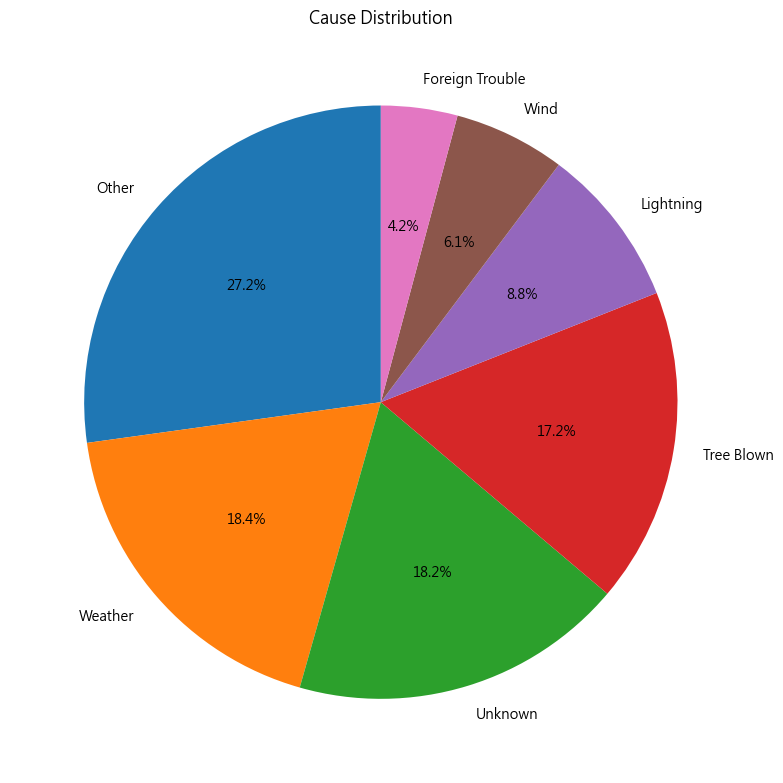

In [26]:
import matplotlib.pyplot as plt

cause_counts = df["Cause"].value_counts()

plt.figure(figsize=(8, 8))
plt.pie(cause_counts, labels=cause_counts.index, autopct="%1.1f%%", startangle=90)
plt.title("Cause Distribution")
plt.tight_layout()
plt.show()

由於 wheather 的比例比我想像中高、確認一下是否有異常事件在某個年度發生

看起來並沒有大型的天氣災害事件

In [27]:
# 各年度 Cause 分布
year_cause = df.groupby(["year", "Cause"]).size().unstack(fill_value=0)
year_cause_pct = year_cause.div(year_cause.sum(axis=1), axis=0).round(3) * 100
year_cause_pct

Cause,Foreign Trouble,Lightning,Other,Tree Blown,Unknown,Weather,Wind
year,,,,,,,
2014,1.8,14.1,29.0,9.6,22.9,17.5,5.3
2015,3.9,5.7,25.3,14.5,17.3,17.9,15.4
2016,6.8,2.1,43.3,12.6,19.3,15.0,1.0
2017,1.9,10.7,29.1,6.8,27.6,15.9,8.0
2018,4.6,9.6,36.4,13.2,14.5,16.5,5.2
2019,5.5,14.9,26.7,24.3,8.8,16.8,3.0
2020,4.3,8.1,22.0,23.8,15.1,21.6,5.0
2021,1.8,7.2,27.7,21.2,14.7,20.9,6.5
2022,4.7,8.4,28.2,14.9,14.4,22.5,7.0


## 2.4 Duration 直方圖

1. 線性直方圖

2. Log 尺度下直方圖

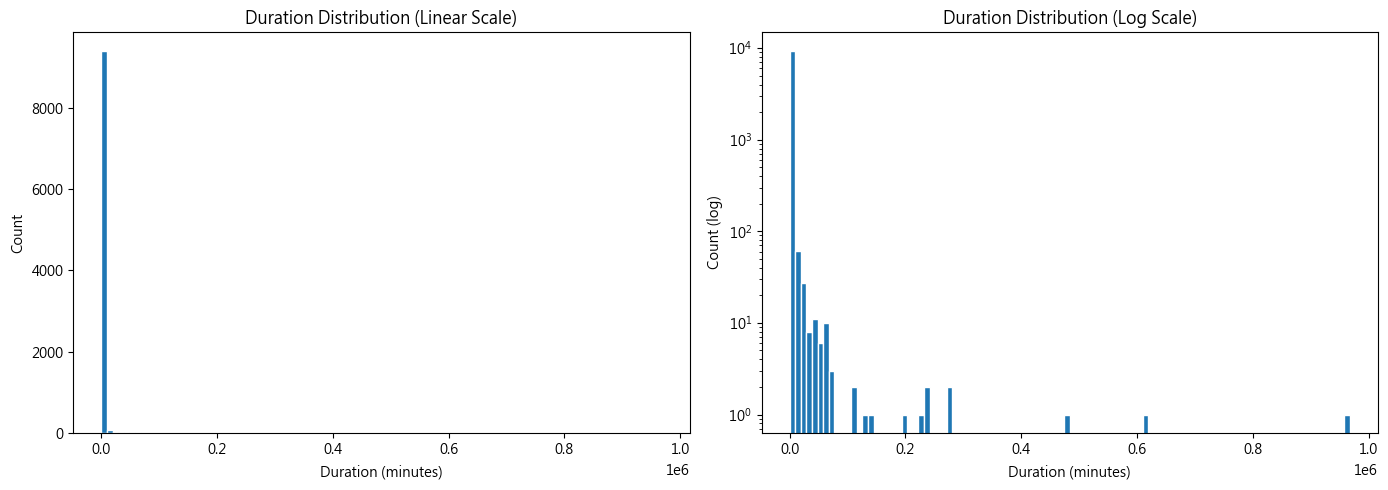

In [28]:
# 2.4 Duration 直方圖
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 線性尺度
axes[0].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[0].set_title("Duration Distribution (Linear Scale)")
axes[0].set_xlabel("Duration (minutes)")
axes[0].set_ylabel("Count")

# Log 尺度
axes[1].hist(df["Duration (minutes)"], bins=100, edgecolor="white")
axes[1].set_yscale("log")
axes[1].set_title("Duration Distribution (Log Scale)")
axes[1].set_xlabel("Duration (minutes)")
axes[1].set_ylabel("Count (log)")

plt.tight_layout()
plt.show()

# 3. CCDF 計算與繪製

* 目的 : 計算並繪製修復時間的經驗互補累積分布函數（CCDF），以 log-log 尺度呈現。若分布具有重尾特性，資料點在 log-log 圖上會呈現近似線性的行為。此圖將作為後續 log-normal 擬合比較的基準。

* 橫軸 : 修復時間（分鐘），以 log 尺度呈現，範圍從 1 分鐘到數萬分鐘，跨越多個數量級。

* 縱軸 : P(X > x) 互補累積機率，即修復時間超過 x 分鐘的機率，以 log 尺度呈現。數值越小代表該修復時間越罕見。

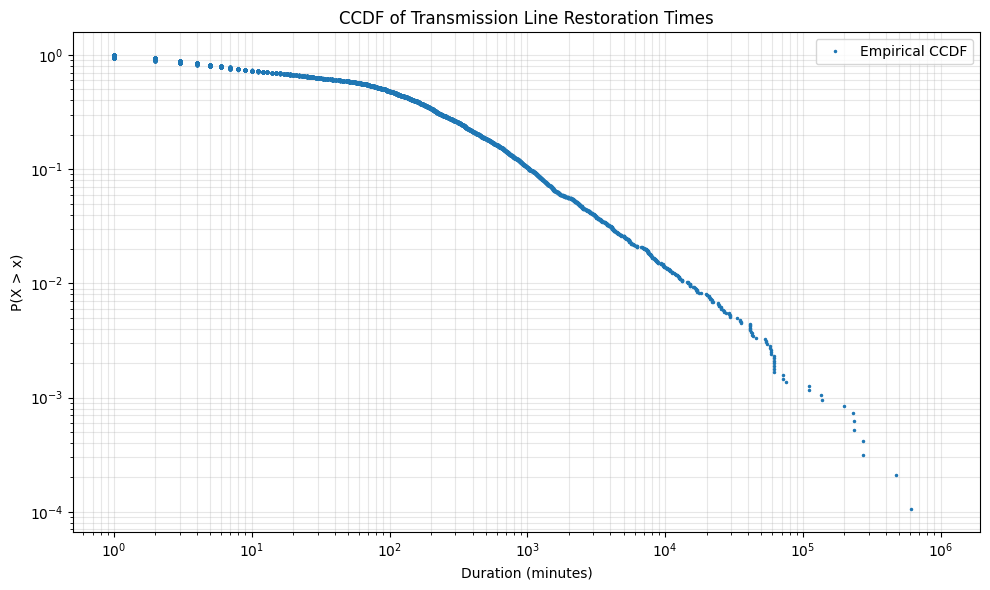

In [ ]:
import numpy as np

# 依據修復時間做排序
duration_sorted = np.sort(df["Duration (minutes)"].values)

# 發生該修復時間的互補累積機率 (1-累積機率)
# 使用 arange 將 numpy 陣列做 [1,2...] 排列，也就是記數
ccdf = 1 - np.arange(1, len(duration_sorted) + 1) / len(duration_sorted)

plt.figure(figsize=(10, 6))
plt.loglog(duration_sorted, ccdf, marker=".", linestyle="none", markersize=3, label="Empirical CCDF")
plt.xlabel("Duration (minutes)")
# 修復時間超過 x 分鐘的機率
plt.ylabel("P(X > x)")
plt.title("CCDF of Transmission Line Restoration Times")
plt.legend()
plt.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()